<a href="https://colab.research.google.com/github/Eng3mr5aled/Machine-Learning-_python/blob/main/Exercise_1_%E2%80%94_Polynomial_Degree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ### Setup:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix

#### Exercise 1 — Polynomial Degree:

In [ ]:
df = pd.read_csv('position_salary.csv')
df.head(20)

,Position,Level,Salary
0,Intern,1,45000
1,Junior,2,50000
2,Associate,3,60000
3,Analyst,4,80000
4,Specialist,5,110000
5,Manager,6,150000
6,Senior Manager,7,200000
7,Director,8,300000
8,VP,9,500000
9,CEO,10,1000000


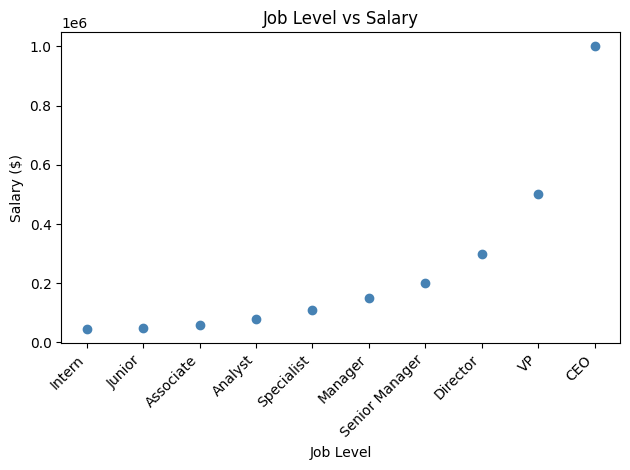

In [ ]:
plt.scatter(df['Level'], df['Salary'], color='steelblue')
plt.xlabel('Job Level')
plt.ylabel('Salary ($)')
plt.title('Job Level vs Salary')
plt.xticks(df['Level'], df['Position'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
X = df[['Level']]
y = df['Salary']
# the polynomial preparation:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

print('Original shape :', X.shape)
print('After poly     :', X_poly.shape)
print('Columns        :', poly.get_feature_names_out())

Original shape : (10, 1)
After poly     : (10, 5)
Columns        : ['1' 'Level' 'Level^2' 'Level^3' 'Level^4']


In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)

print(f'Polynomial (degree 4) R² = {r2_score(y, y_pred_poly):.4f}')

Polynomial (degree 4) R² = 0.9974


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


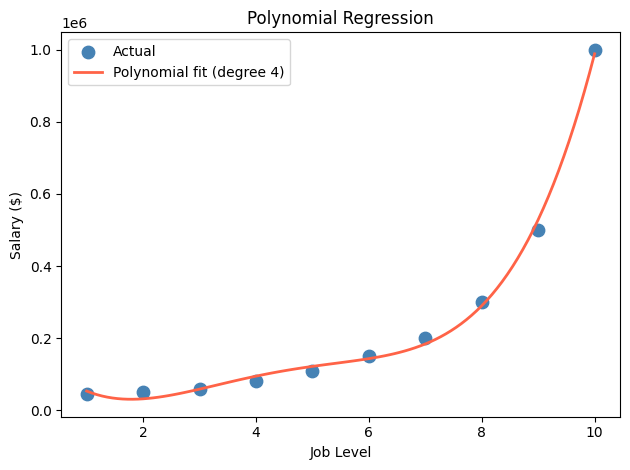

the polynomial Regression with (degree = 4) is overfit the data 


In [ ]:
x_range = np.linspace(X['Level'].min(), X['Level'].max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)

plt.scatter(df['Level'], df['Salary'], color='steelblue', s=80, label='Actual')
#plt.plot(x_range, linear_model.predict(x_range),       color='gray',   lw=1.5, linestyle='--', label='Linear fit')
plt.plot(x_range, poly_model.predict(x_range_poly),    color='tomato', lw=2,   label='Polynomial fit (degree 4)')
plt.xlabel('Job Level')
plt.ylabel('Salary ($)')
plt.title('Polynomial Regression')
plt.legend()
plt.tight_layout()
plt.show()
print("the polynomial Regression with (degree = 4) is overfit the data ")